### Business Problem:
##### The company is losing employees at a high rate, which increases hiring cost and reduces productivity.

#### EDA Goal:

+ Who is leaving?

+ From which department?

+ At what salary level?

+ After how many years?

+ Is overtime linked to attrition?

+ Does job satisfaction affect exits?

##### This is the classic problem in HR datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\thiru\Downloads\WA_Fn-UseC_-HR-Employee-Attrition.csv")
df

,Employee ID,Age,Attrition,Business Travel,Department,Distance From Home,Education,Education Field,Environment Satisfaction,Gender,Job Involvement,Job Role,Job Satisfaction,Marital Status,Monthly Income,Experience,Over Time,WorkLifeBalance,Performance Rating
0,1.0,41.0,Yes,Travel_Rarely,Sales,1.0,Intermediate,Life Sciences,2.0,Female,High,Sales Executive,4.0,Single,"$5,993",8.0,Yes,1.0,3.0
1,2.0,49.0,No,Travel_Frequently,Research & Development,8.0,SSC,Life Sciences,3.0,Male,Medium,Research Scientist,2.0,Married,"$5,130",1.0,No,3.0,4.0
2,4.0,37.0,Yes,Travel_Rarely,Research & Development,2.0,Intermediate,Medical,4.0,Male,Medium,Laboratory Technician,3.0,Single,"$2,090",6.0,Yes,3.0,3.0
3,5.0,33.0,No,Travel_Frequently,Research & Development,3.0,Masters,Life Sciences,4.0,Female,High,Research Scientist,3.0,Married,"$2,909",1.0,Yes,3.0,3.0
4,7.0,27.0,No,Travel_Rarely,Research & Development,2.0,SSC,Medical,1.0,Male,High,Laboratory Technician,2.0,Married,"$3,468",9.0,No,3.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1466,2062.0,39.0,No,Travel_Rarely,Research & Development,6.0,SSC,Medical,4.0,Male,Medium,Healthcare Representative,1.0,Married,"$9,991",4.0,No,3.0,3.0
1467,2064.0,27.0,No,Travel_Rarely,Research & Development,4.0,Graduate,Life Sciences,2.0,Male,Very High,Manufacturing Director,2.0,Married,"$6,142",1.0,Yes,3.0,4.0
1468,2065.0,49.0,No,Travel_Frequently,Sales,2.0,Graduate,Medical,4.0,Male,Medium,Sales Executive,2.0,Married,"$5,390",2.0,No,2.0,3.0
1469,2068.0,34.0,No,Travel_Rarely,Research & Development,8.0,Graduate,Medical,2.0,Male,Very High,Laboratory Technician,3.0,Married,"$4,404",2.0,No,4.0,3.0


## Data Cleaning

In [11]:
df.isna().sum() 
# Each column except Education has 1 missing value, so overall the solution is dropping or filling numericals with mean and categotical with mode.
# so I've choosen dropping instead of filling b'coz of we have just 1 row is  missing in overall dataset.

Employee ID                 1
Age                         1
Attrition                   1
Business Travel             1
Department                  1
Distance From Home          1
Education                   0
Education Field             1
Environment Satisfaction    1
Gender                      1
Job Involvement             1
Job Role                    1
Job Satisfaction            1
Marital Status              1
 Monthly Income             1
Experience                  1
Over Time                   1
WorkLifeBalance             1
Performance Rating          1
dtype: int64

In [33]:
df.isnull().sum().sum()

np.int64(18)

In [34]:
df.dropna(inplace = True)

In [35]:
df.isna().sum() 

Employee ID                 0
Age                         0
Attrition                   0
Business Travel             0
Department                  0
Distance From Home          0
Education                   0
Education Field             0
Environment Satisfaction    0
Gender                      0
Job Involvement             0
Job Role                    0
Job Satisfaction            0
Marital Status              0
 Monthly Income             0
Experience                  0
Over Time                   0
WorkLifeBalance             0
Performance Rating          0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [3]:
df.rename(columns={' Monthly Income ': 'Monthly_Income','Employee ID' :'Employee_ID','Business Travel' : 'BusinessTravel','Distance From Home' : 'Distance_From_Home','Education Field' : 'Education_Field','Environment Satisfaction' : 'Environment_Satisfaction','Job Involvement' : 'Job_Involvement','Job Role' : 'Job_Role','Job Satisfaction' : 'Job_Satisfaction','Marital Status' : 'Marital_Status','Over Time' : 'Over_Time','WorkLifeBalance' : 'Work_Life_Balance','Performance Rating' : 'Performance_Rating'}, inplace=True) # renamed

In [4]:
df.columns

Index(['Employee_ID', 'Age', 'Attrition', 'BusinessTravel', 'Department',
       'Distance_From_Home', 'Education', 'Education_Field',
       'Environment_Satisfaction', 'Gender', 'Job_Involvement', 'Job_Role',
       'Job_Satisfaction', 'Marital_Status', 'Monthly_Income', 'Experience',
       'Over_Time', 'Work_Life_Balance', 'Performance_Rating'],
      dtype='object')

In [14]:
df['Monthly_Income']

0        $5,993 
1        $5,130 
2        $2,090 
3        $2,909 
4        $3,468 
          ...   
1466     $9,991 
1467     $6,142 
1468     $5,390 
1469     $4,404 
1470         NaN
Name: Monthly_Income, Length: 1471, dtype: object

In [15]:
df['Monthly_Income'] = (
    df['Monthly_Income']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

df['Monthly_Income'] = pd.to_numeric(df['Monthly_Income'], errors='coerce') #3

In [16]:
df['Monthly_Income']

0       5993.0
1       5130.0
2       2090.0
3       2909.0
4       3468.0
         ...  
1466    9991.0
1467    6142.0
1468    5390.0
1469    4404.0
1470       NaN
Name: Monthly_Income, Length: 1471, dtype: float64

#### Statstical Measures

In [17]:
df['Monthly_Income'].describe().round(2)

count     1470.00
mean      6502.93
std       4707.96
min       1009.00
25%       2911.00
50%       4919.00
75%       8379.00
max      19999.00
Name: Monthly_Income, dtype: float64

## Univarite Analysis

#### Attrition Count

[Text(0, 0, '237'), Text(0, 0, '1233')]

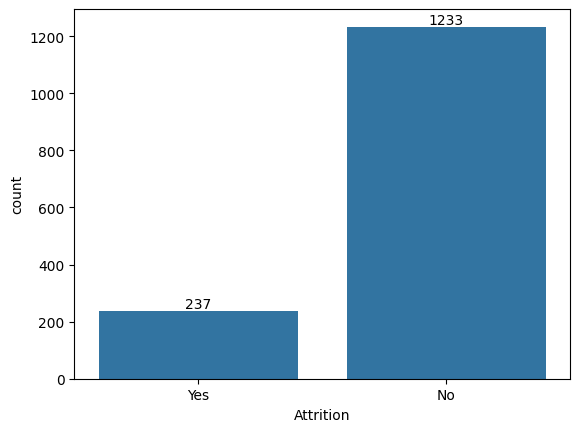

In [24]:
a=sns.countplot( x = 'Attrition', data = df ) # Majority of employees are retained by the organization.
a.bar_label(a.containers[0])

#### Insights :
+ 237 Peoples have left their company.

#### Distribution of Job Roles

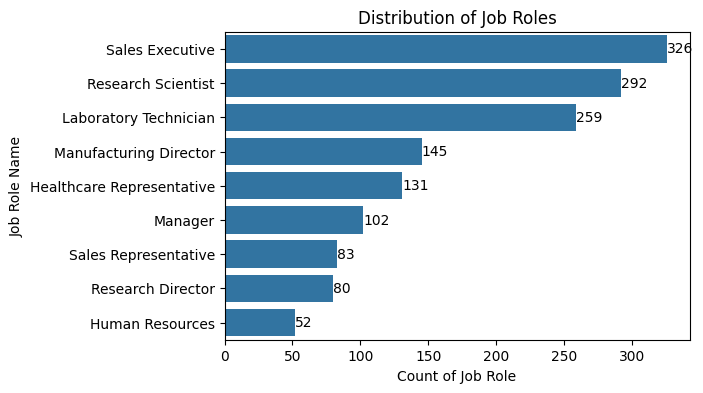

In [135]:
plt.figure(figsize=(6,4))
a = sns.countplot(df['Job_Role'])

for container in a.containers:
    a.bar_label(container)

plt.xlabel("Count of Job Role")
plt.ylabel("Job Role Name")
plt.title("Distribution of Job Roles")

plt.show()

#### Insights :
+ In Sales Executive role we have highest employees than comparing to other job roles.
+ The lowest employee count is in Human Resources.

#### Distribution of Employees Age

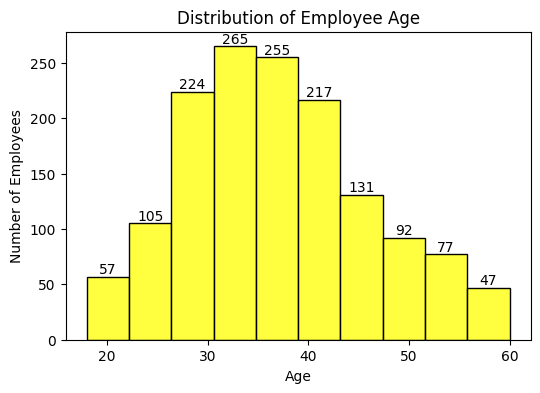

In [59]:
plt.figure(figsize=(6,4))
a = sns.histplot(df['Age'], bins=10, color = 'yellow')

for container in a.containers:
    a.bar_label(container)

plt.xlabel("Age")
plt.ylabel("Number of Employees")
plt.title("Distribution of Employee Age")

plt.show()

#### Insights :
+ Most employees are approximately aged between 28 yrs to 45 yrs old.

#### Outliers of Monthly Income

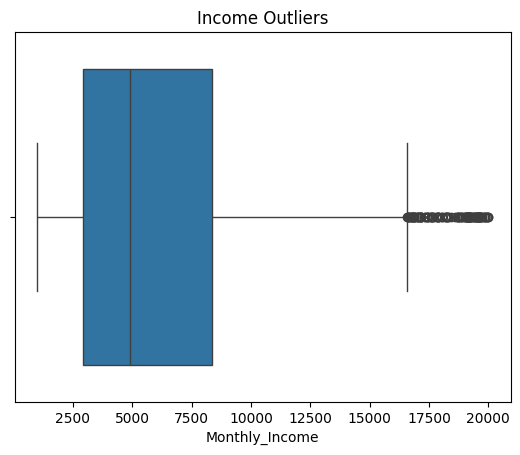

In [143]:
sns.boxplot(x=df['Monthly_Income'])
plt.title("Income Outliers")
plt.show()

#### Insights :
+ Median of monthly income is 4919.
+ Max of monthly income is 19999.
+ Some employees are earning more than $17500 and we can call them as our outliers.

#### Outliers of employees experience

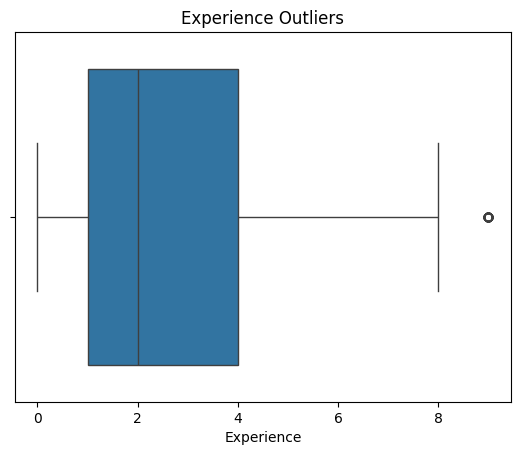

In [144]:
sns.boxplot(x=df['Experience'])
plt.title("Experience Outliers")
plt.show()

In [29]:
df['Experience'].median()

2.0

In [30]:
df['Experience'].max()

9.0

#### Insights :
+ Avrg experience of employee is 2yrs.
+ Some employees are having 9+ yrs of experience that we can call them as outliers.

## BI Variate Analysis

#### Does Monthly Income influence Attrition?

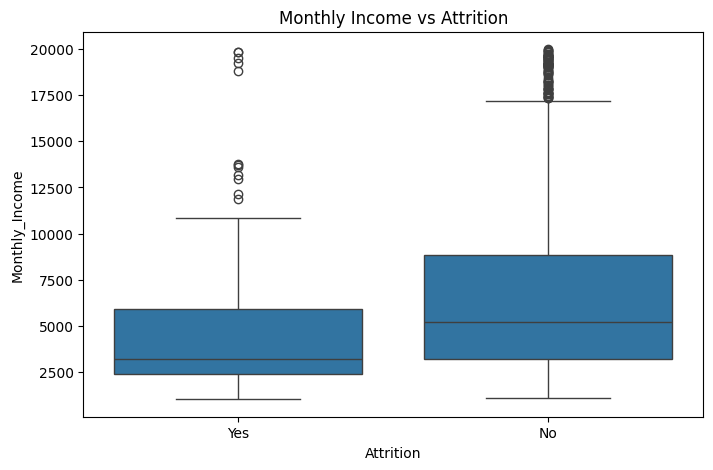

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Attrition', y='Monthly_Income', data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

In [28]:
df.groupby('Attrition')['Monthly_Income'].median()

Attrition
No     5204.0
Yes    3202.0
Name: Monthly_Income, dtype: float64

#### Insights :
##### Median comparison

+ Attrition = Yes, median salary is clearly lower around 3500.

+ Attrition = No, median salary is higher around 5000.

#### Does Age influence Attrition?

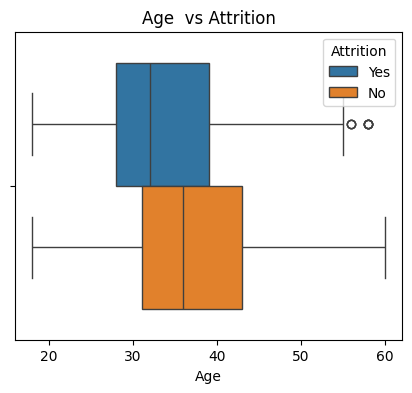

In [33]:
plt.figure(figsize=(5,4))
a=sns.boxplot(x='Age', hue='Attrition', data=df)
plt.title('Age  vs Attrition')
plt.show()

In [35]:
df['Age'].median()

36.0

#### Insights :
+ Employees who stayed (No) have a wider age range.
+ Employees who left are more in younger age groups.
+ Very few older employees (50+) are leaving.
+ Most older employees remain in the company.

#### Does OverTime influence Attrition?

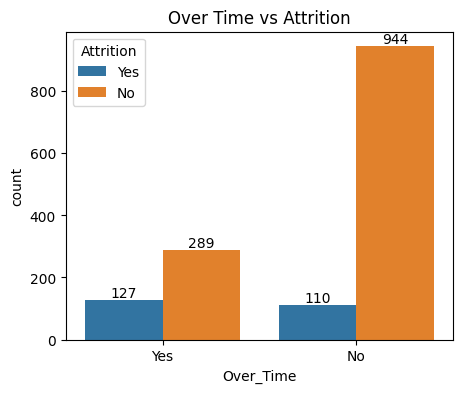

In [55]:
plt.figure(figsize=(5,4))
a=sns.countplot(x='Over_Time', hue='Attrition', data=df)
plt.title('Over Time vs Attrition')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.show()

#### Insights :
+ ##### Overtime doesn't effect attrition.
+ There is total 1470 employees and especially there is 416 employees who are doing overtime, in this case just 127 employees are left from organization.
+ And in another case 1054 employees are can't do over time still 110 employees are in attrition list.
+ ##### So overall I conclude that - Overtime doesn't effect attrition.

#### Gender Wise Attrition

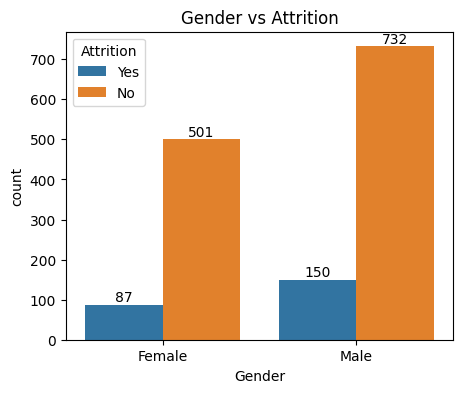

In [36]:
plt.figure(figsize=(5,4))
a=sns.countplot(x='Gender', hue='Attrition', data=df)
plt.title('Gender vs Attrition')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.show()

#### Insights : 
+ We've 2 genders in our dataset, so in gender there is more attrition in Males while comparing to Females.
+ In Males there are 782 employees and 150 employees have left their organization.
+ In Females there are 588 employees and 87 employees have left.

#### Department Wise Attrition

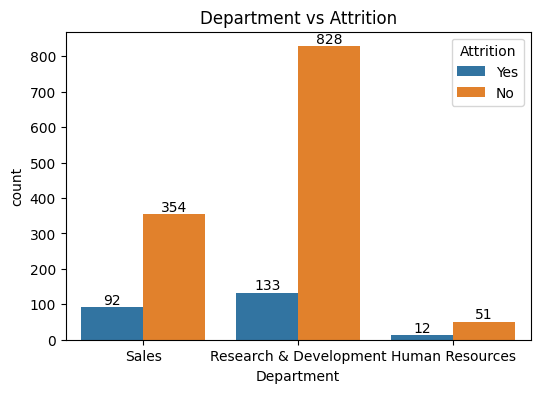

In [50]:
plt.figure(figsize=(6,4))
a = sns.countplot(x='Department', hue='Attrition', data=df)
plt.title('Department vs Attrition')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.show()

In [29]:
df.groupby(['Attrition','Department'])['Monthly_Income'].median()

Attrition  Department            
No         Human Resources           4936.0
           Research & Development    4708.0
           Sales                     6073.5
Yes        Human Resources           2652.5
           Research & Development    2759.0
           Sales                     5314.0
Name: Monthly_Income, dtype: float64

#### Insights :
+ Here are 3 departments in our dataset those - " Sales, Research & Development and Human Resources Department ".
+ According to each department we've more attrition in Research & Development Department while comparing to others.
+ Human Resources Department has less attrition.

#### Job Role Wise Attrition

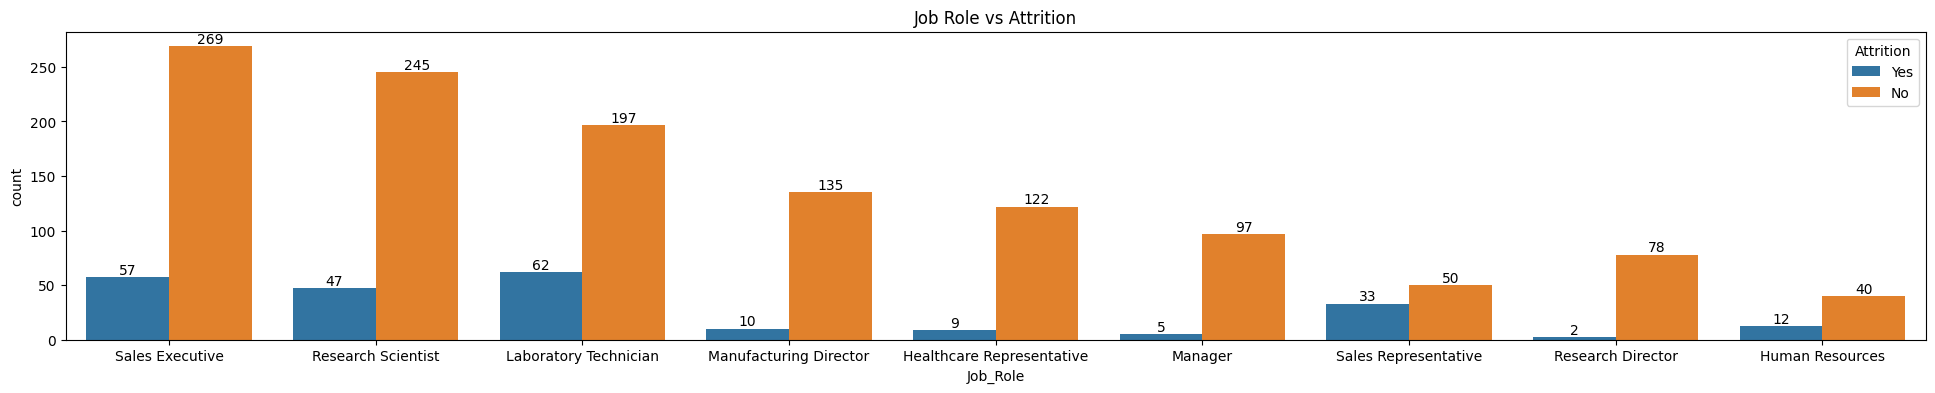

In [44]:
plt.figure(figsize=(24,4))
a = sns.countplot(x='Job_Role', hue='Attrition', data=df)
plt.title('Job Role vs Attrition')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.show()

In [47]:
df.groupby(['Attrition','Job_Role'])['Monthly_Income'].mean().round(2)

Attrition  Job_Role                 
No         Healthcare Representative     7453.56
           Human Resources               4391.75
           Laboratory Technician         3337.22
           Manager                      17201.48
           Manufacturing Director        7289.93
           Research Director            15947.35
           Research Scientist            3328.12
           Sales Executive               6804.62
           Sales Representative          2798.44
Yes        Healthcare Representative     8548.22
           Human Resources               3715.75
           Laboratory Technician         2919.26
           Manager                      16797.40
           Manufacturing Director        7365.50
           Research Director            19395.50
           Research Scientist            2780.47
           Sales Executive               7489.00
           Sales Representative          2364.73
Name: Monthly_Income, dtype: float64

#### Insights :
+ Manager and Research Directors Job Roles are earning higher salary than other Job Roles that's why those both Job Roles have less attrition.
+ In Sales Executive, Research Scientist and Laboratory Technician have more attrition than others but Sales Executive employees are earning verry good salary (7489) but still it has more attrition, just conclude that : only salary doesn't effect attrition.
+ Research Scientist, Sales Representative and Laboratory Technician Roles employees are earning less salary that's why attrition count is high in those Job Roles.

#### Does Distance From Home affect Attrition?

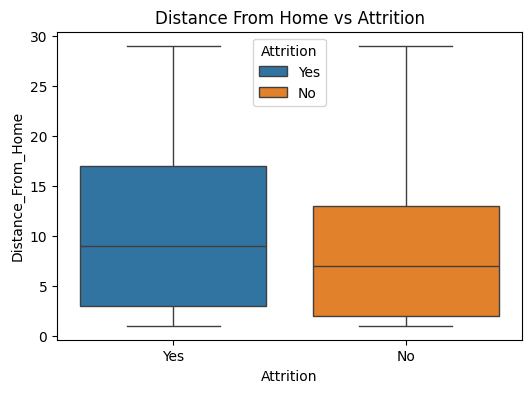

In [53]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='Distance_From_Home',hue='Attrition', data=df)
plt.title('Distance From Home vs Attrition')
plt.show()  

In [43]:
df['Distance_From_Home'].mean()

np.float64(9.19251700680272)

In [42]:
df.groupby('Attrition')['Distance_From_Home'].mean()

Attrition
No      8.915653
Yes    10.632911
Name: Distance_From_Home, dtype: float64

#### Insights :
+ Employees who leave the company usually live a bit farther away, but distance alone isn’t a major reason to why employees quit.

#### Performance Rating Wise Attrition

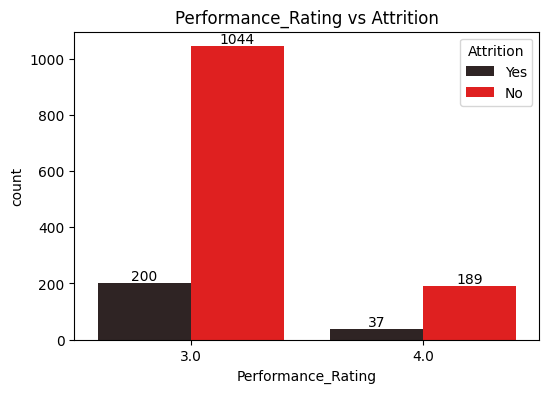

In [8]:
plt.figure(figsize=(6,4))
a = sns.countplot(x='Performance_Rating', hue='Attrition', data=df, color = 'red')
plt.title('Performance_Rating vs Attrition')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.show()

+ Rating 3

Total = 1244
Attrition Yes = 200 (16%).

+ Rating 4

Total = 226
Attrition Yes = 37 (16%).

+ The attrition percentage is almost the same.
+ Performance rating does not show a significant impact on attrition, as the proportion of employees leaving is similar across ratings 3 and 4.

#### Employee Satisfaction & Work-Life Balance :

#### Does Job Satisfaction affect Attrition?

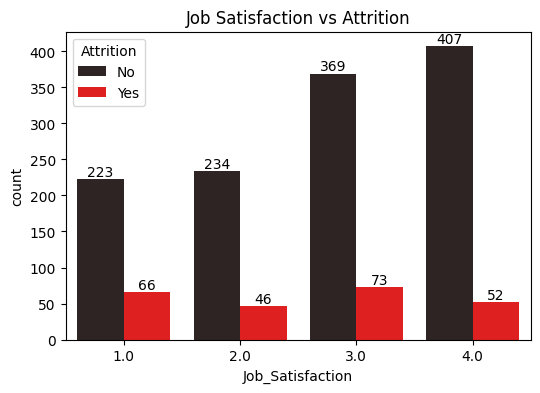

In [60]:
plt.figure(figsize=(6,4))
a = sns.countplot(x='Job_Satisfaction', hue='Attrition', data=df, color = 'red')
plt.title('Job Satisfaction vs Attrition')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.show()

#### Insights :
+ Low satisfaction (1) highest number of employees leaving.
+ Medium satisfaction (2 & 3) fewer employees leaving.
+ High satisfaction (4) attrition drops again.
+ ##### Employees who stay are much higher at job satisfaction level 3 & 4.

+ ##### In final I conlude that : Employees with lower job satisfaction are more likely to leave, while higher satisfaction levels are linked to better employee retention.

#### Does Environment Satisfaction affect Attrition?

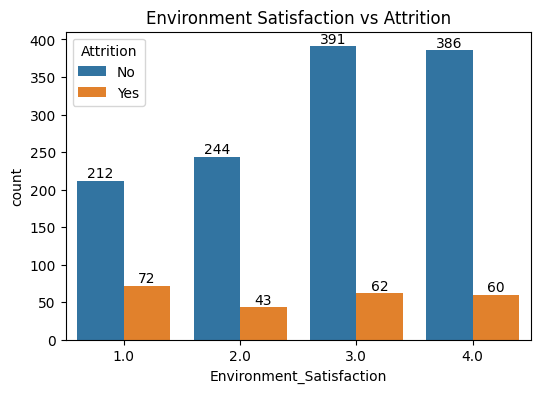

In [64]:
plt.figure(figsize=(6,4))
a = sns.countplot(x='Environment_Satisfaction', hue='Attrition', data=df)
plt.title('Environment Satisfaction vs Attrition')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.show()

#### Insights :
+ in this case total 284 employees are having less Environment Satisfaction (1).
+ There is more employees are leaving who's having less Environment Satisfaction when comparing to others.
+ Majority employees are having (3 & 4) Environment Satisfaction, they likes the environemnt that's why they are staying.
+ ##### Low job enviromnet staisfaction affects attrition.

#### Does Work Life Balance affect Attrition?

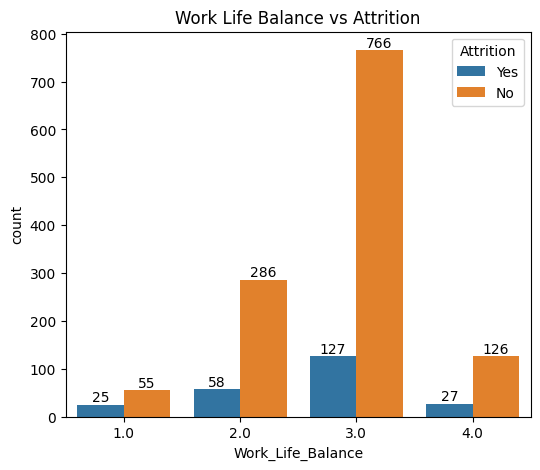

In [22]:
plt.figure(figsize=(6,5))
a = sns.countplot(x='Work_Life_Balance', hue='Attrition', data=df)
plt.title('Work Life Balance vs Attrition')
a.bar_label(a.containers[0])
a.bar_label(a.containers[1])
plt.show()

#### Insights :

+ Who are maintained very good Work Life Balance employees are leaving their organization.
+ There is less attrition of employees who're having less Work Life Balance.
+ It means Work Life Balance doesn't effect attrition.

## Multi Variate Analysis

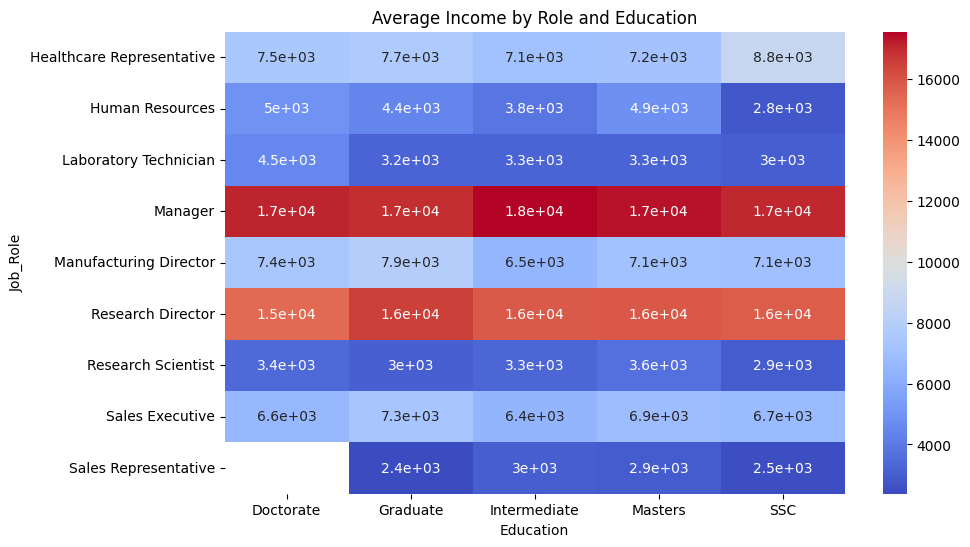

In [41]:
pivot = df.pivot_table(
    values='Monthly_Income',
    index='Job_Role',
    columns='Education',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Average Income by Role and Education')
plt.show()

#### Insights :
+ Monthly income varies significantly by job role, with manager and director level positions earning the highest salaries.
+ Education level has a comparatively smaller impact on income.
+ This suggests that job position and seniority play more critical role in salary than educational qualifications.

### Bussiness Problem Statement

+ We've more attrition in Research & Development department.

+ Younger employees show higher attrition compared to older employees, indicating that age may influence employee retention.

+ Overtime doesn't effect attrition, Because of both employees who are doing overtime and don't are have leaving the company at almost same number.

+ Work Life Balance doesn't effect attrition.

+ Employees who stay are much higher at job satisfaction level 3 & 4. Employees with lower job satisfaction are leaving.

+ Majority employees are having (3 & 4) Environment Satisfaction, they likes the environemnt that's why they are staying. Low job enviromnet staisfaction affects attrition.

+ Employees with lower monthly income are more likely to leave, indicating salary is a significant factor influencing attrition.

+ Few Job Roles are having less Monthly Income that's why more attrtion is happening.